# Découvrez le principe de la régression linéaire

1 - cas 1 : prédire une variable y à partir d'une variable de prédiction x .

Equation : y = a * x + b

2 - cas 2 : prédiction d'une variable y à partir de deux variables de prédiction $x_1 \ et \   x_2$ .

Equation : $y=a_1*x_1 + b_2*x_2 + b$

3 - cas 3 : on veut prédire y à partir de N variables prédictives.

Equation :
$y= a_1*x_1+a_2*x_2 + \ldots + a_N * x_N +b$

En abrégé on a : y ~ $x_1+x_2+x_N$

**note** : `b` est appelé l'interception .

- variable cible / variable dépendante / variable endogène 

- variable de prédiction / variable d'entrée / variable endogène / variable exogène


# Les limites de la régression linéaire

- Limite n° 1 : Utiliser une régression linéaire à partir d’un cas non linéaire ne marchera pas

- Limite n° 2 : des variations d'amplitude significative peuvent fausser l'importance des coefficients


# Regression 

Variable cible :  ventes  (  sales  dans la version originale).

Prédicteurs : budgets de publicité :

pour la TV :  tv  ;

pour la la radio :  radio  ;

pour la presse :  journaux  (  newspaper  dans la version originale).


In [1]:
# les imports
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# chargement du dataset
df = pd.read_csv('../data/advertising.csv')

# affichage des dimensions
df.shape

(200, 4)

In [3]:
# affichage d'un extrait du dataframe
df.head()

,tv,radio,journaux,ventes
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
# affichage de quelques statistiques
df.describe()

,tv,radio,journaux,ventes
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## Verification des relations linéaires entre les prédicteurs et la variable cible

In [5]:
def show_regplot(data:pd.DataFrame,x:str):
    """_summary_

    Args:
        data (pd.DataFrame): le dataframe
        x (str): le predicteur
    """

    # initialisation de la figure
    plt.figure(figsize=(7,6))

    # graphique
    sns.regplot(data=df,x=x,y='ventes')

    # labels des axes
    plt.xlabel(x)
    plt.ylabel('ventes')

    # titre du graphique
    plt.title(f"ventes = a * {x} + b")

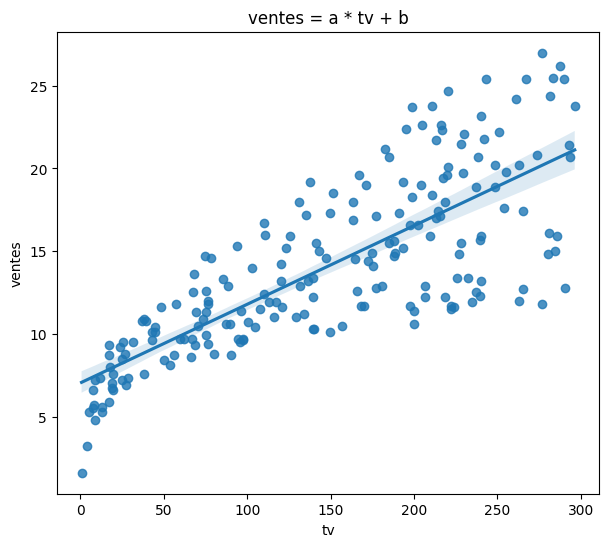

In [6]:
tv_plot=show_regplot(data=df,x='tv')

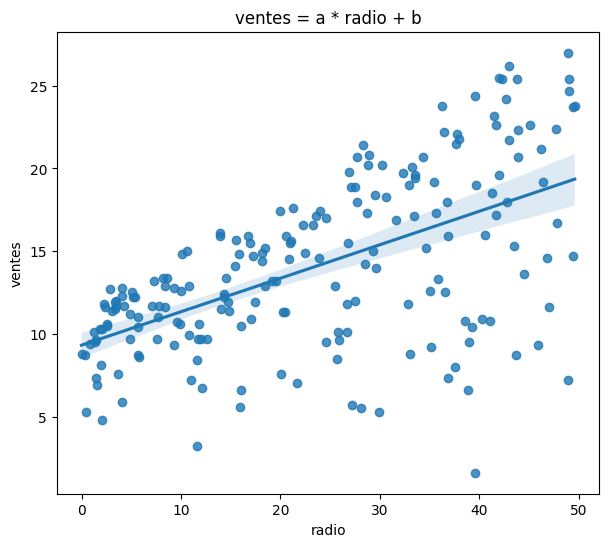

: 

In [ ]:
radio_plot = show_regplot(data=df, x="radio")

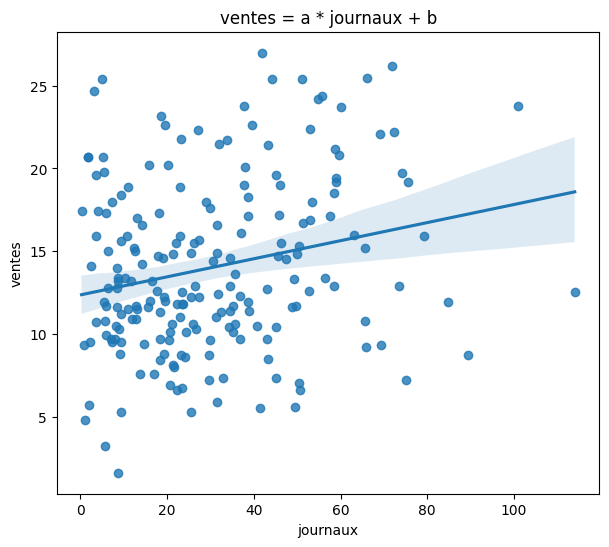

In [7]:
journaux_plot = show_regplot(data=df, x="journaux")

La zone bleue reflète l'incertitude du modèle , plus elle est grande , moins la regression est fiable . 

D'après les graphiques , on a du plus au moins prédictive : tv > radio > journaux

Vérifions par les coefficients de corrélation

In [8]:
df.corr().loc['ventes']

tv          0.782224
radio       0.576223
journaux    0.228299
ventes      1.000000
Name: ventes, dtype: float64

In [9]:
# instanciation du modèle
reg = LinearRegression()

Maintenant on va séparer les données en données d'entrainement et données de test.

On va utiliser 20% des données pour les tests.

la valeur de random state permet de s'assurer de la reproductibilité des resultats.

In [10]:
from sklearn.model_selection import train_test_split

X = df[['tv','radio','journaux']]
y = df['ventes']

X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
# entrainement du modèle
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
# recuperation des résultats de la prédiction
# des tests pour évaluer le modèle
y_pred_test = reg.predict(X_test)

Utilisons la RMSE et la MAPE comme scores. Pour ces 2 métriques, un score plus petit correspond à un meilleur modèle. MAPE est comprise entre 0 et 1, tandis que RMSE n'est pas contrainte.

In [13]:
from sklearn.metrics import mean_squared_error , mean_absolute_percentage_error

print(f"RMSE = {mean_squared_error(y_test,y_pred_test)}")

print(f"MAPE = {mean_absolute_percentage_error(y_test,y_pred_test)}")

RMSE = 3.174097353976104
MAPE = 0.15198846602831229


Est-ce un bon ou un mauvais score ?

Difficile à dire, comme la RMSE n'est pas absolue. Une MAPE de 0,15 semble bien, car plus proche de 0 que de 1.

Amélioration n° 1 : Ajouter un terme quadratique
le nuage de point de tv semble suivre une courbe qu'une droite
on peut donc avoir ` ventes=a∗tv+b∗tv2+c`

**Lorsqu'on ajoute une puissance de l'une des variables dans la régression, on fait ce qu'on appelle une régression polynomiale.**

Avant d'entraîner ce nouveau modèle, on remarque que l'amplitude de  tv2  va être bien plus grande que celle des autres variables. On va donc normaliser les variables, pour que leurs amplitudes soient compatibles.

In [14]:
# créons la nouvelle variable
df['tv2'] = df.tv **2

In [25]:
# importation du scaler
from sklearn.preprocessing import MinMaxScaler

# instanciation
scaler = MinMaxScaler()

# array normalisé
data_array = scaler.fit_transform(df)

# transformation en dataframe
df = pd.DataFrame(data_array,columns=['tv','radio','journaux','ventes','tv2'])

In [26]:
# verification
df.describe().loc[['min','max']]

,tv,radio,journaux,ventes,tv2
min,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0


# Regression polynomiale
on a : `y ~ tv + radio + journaux + tv2`

In [27]:
X = df[["tv", "radio", "journaux", "tv2"]]

y = df.ventes

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

reg.fit(X_train,y_train)

y_hat_pred_test = reg.predict(X_test)

print(f"coefficients:{reg.coef_}")

print(f"RMSE: {mean_squared_error(y_test, y_hat_pred_test)}")

print(f"MAPE: {mean_absolute_percentage_error(y_test, y_hat_pred_test)}")

coefficients:[ 0.88007136  0.37464292  0.02197664 -0.36578279]
RMSE: 0.0036863988616064646
MAPE: 0.16200182799935664


On note une nette amélioration par rapport au premier modèle.

Il est possible d'aller encore plus loin en ajoutant le terme croisé  tv * radio  qui reflète l'effet cumulé d'une campagne de pub qui soit à la fois à la radio et à la télévision.

In [35]:
# variable tv_radio
df['tv_radio'] = df.tv*df.radio

df = pd.DataFrame(scaler.fit_transform(df),columns=[
    'tv',
    'radio',
    'journaux',
    'ventes',
    'tv2',
    'tv_radio'
])


X = df[['tv','radio','journaux','tv2','tv_radio']]
y = df.ventes

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

reg.fit(X_train,y_train)

y_hat_cross_pred = reg.predict(X_test)

print(f"coefficients:{reg.coef_}")

print(f"RMSE: {mean_squared_error(y_test, y_hat_cross_pred)}")

print(f"MAPE: {mean_absolute_percentage_error(y_test, y_hat_cross_pred)}")

coefficients:[ 0.60221495  0.06911035  0.01859556 -0.3846345   0.56589688]
RMSE: 0.0005689355134662454
MAPE: 0.05976165903177542


Le dernier modèle bat tous les records.